# Importing Libraries 

In [23]:
# Importing Libraries 
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.ensemble import RandomForestClassifier

In [24]:
df_train = pd.read_csv('train.csv')
print(df_train.shape)

df_test = pd.read_csv('test.csv')
print(df_test.shape)

(38, 7131)
(34, 7131)


In [25]:
df_train.head()

,Unnamed: 0,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,cancer
0,0,-214,-153,-58,88,-295,-558,199,-176,252,...,511,-125,389,-37,793,329,36,191,-37,0
1,1,-139,-73,-1,283,-264,-400,-330,-168,101,...,837,-36,442,-17,782,295,11,76,-14,0
2,2,-76,-49,-307,309,-376,-650,33,-367,206,...,1199,33,168,52,1138,777,41,228,-41,0
3,3,-135,-114,265,12,-419,-585,158,-253,49,...,835,218,174,-110,627,170,-50,126,-91,0
4,4,-106,-125,-76,168,-230,-284,4,-122,70,...,649,57,504,-26,250,314,14,56,-25,0


In [26]:
df_test.head()

,Unnamed: 0,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,...,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at,cancer
0,0,-342,-200,41,328,-224,-427,-656,-292,137,...,1023,67,214,-135,1074,475,48,168,-70,0
1,1,-87,-248,262,295,-226,-493,367,-452,194,...,529,-295,352,-67,67,263,-33,-33,-21,0
2,2,22,-153,17,276,-211,-250,55,-141,0,...,399,16,558,24,893,297,6,1971,-42,0
3,3,-243,-218,-163,182,-289,-268,-285,-172,52,...,277,6,81,2,722,170,0,510,-73,0
4,4,-130,-177,-28,266,-170,-326,-222,-93,10,...,643,51,450,-46,612,370,29,333,-19,0


# Splitting the dataset

In [27]:
x_train = df_train.iloc[:,:-1]
y_train = df_train.iloc[:,-1:]
x_test = df_test.iloc[:,:-1]
y_test = df_test.iloc[:,-1:]
x_train.head()

,Unnamed: 0,AFFX-BioB-5_at,AFFX-BioB-M_at,AFFX-BioB-3_at,AFFX-BioC-5_at,AFFX-BioC-3_at,AFFX-BioDn-5_at,AFFX-BioDn-3_at,AFFX-CreX-5_at,AFFX-CreX-3_at,...,U48730_at,U58516_at,U73738_at,X06956_at,X16699_at,X83863_at,Z17240_at,L49218_f_at,M71243_f_at,Z78285_f_at
0,0,-214,-153,-58,88,-295,-558,199,-176,252,...,185,511,-125,389,-37,793,329,36,191,-37
1,1,-139,-73,-1,283,-264,-400,-330,-168,101,...,169,837,-36,442,-17,782,295,11,76,-14
2,2,-76,-49,-307,309,-376,-650,33,-367,206,...,315,1199,33,168,52,1138,777,41,228,-41
3,3,-135,-114,265,12,-419,-585,158,-253,49,...,240,835,218,174,-110,627,170,-50,126,-91
4,4,-106,-125,-76,168,-230,-284,4,-122,70,...,156,649,57,504,-26,250,314,14,56,-25


In [28]:
y_train.head()

,cancer
0,0
1,0
2,0
3,0
4,0


# Training the model

In [29]:
rf_model = RandomForestClassifier(random_state=0)

rf_model.fit(x_train, y_train.values)

rf_pred = rf_model.predict(x_test)
accuracy_score(y_test, rf_pred)

C:\Users\renus\anaconda3\anaconda\Lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


0.6470588235294118

In [30]:
confusion_matrix(y_test, rf_pred )

array([[18,  2],
       [10,  4]])

In [31]:
# Training the Random Forest model
rf_model = RandomForestClassifier(random_state=0)
rf_model.fit(x_train, y_train.values.ravel())

# Making predictions
rf_pred = rf_model.predict(x_test)

# Evaluating model performance
acc = accuracy_score(y_test, rf_pred)
cm = confusion_matrix(y_test, rf_pred)
cr = classification_report(y_test, rf_pred)

print("\nModel Accuracy:", round(acc * 100, 2), "%")
print("\nConfusion Matrix:\n", cm)
print("\nClassification Report:\n", cr)



Model Accuracy: 64.71 %

Confusion Matrix:
 [[18  2]
 [10  4]]

Classification Report:
               precision    recall  f1-score   support

           0       0.64      0.90      0.75        20
           1       0.67      0.29      0.40        14

    accuracy                           0.65        34
   macro avg       0.65      0.59      0.57        34
weighted avg       0.65      0.65      0.61        34



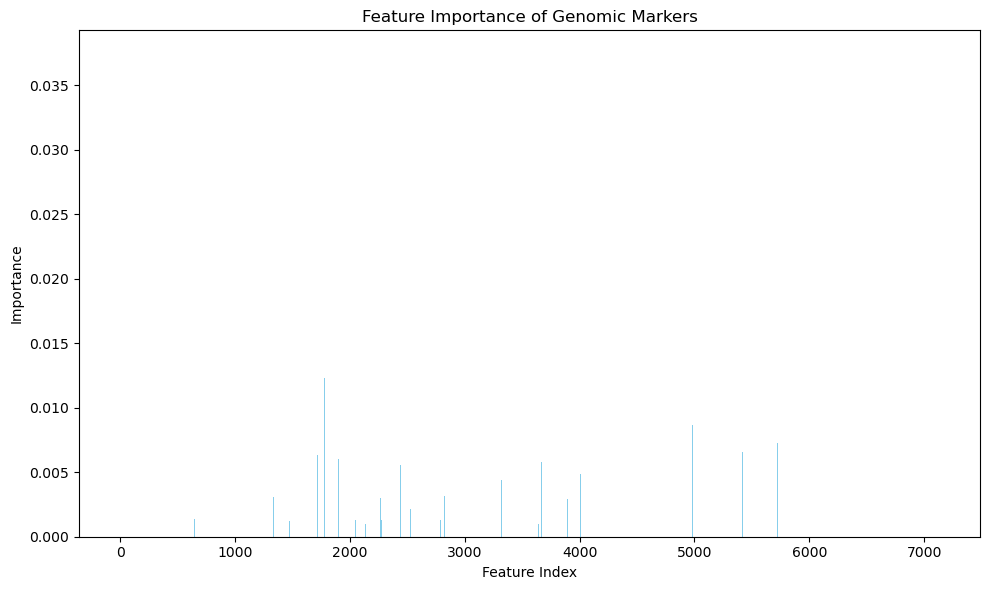

In [22]:
importances = rf_model.feature_importances_
plt.figure(figsize=(10,6))
plt.bar(range(len(importances)), importances, color='skyblue')
plt.title("Feature Importance of Genomic Markers")
plt.xlabel("Feature Index")
plt.ylabel("Importance")
plt.tight_layout()
plt.show()
